<a href="https://colab.research.google.com/github/RachitGandhi13/BFHLChallenge/blob/main/Campus_Attendance_System_Batch18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Campus Attendance System — 21CSS303T Data Science

**Topic:** Real-world attendance tracking system for a university campus.
**Goal:** Identify attendance patterns across departments, courses, genders, and years to help faculty/administrators improve student engagement.

All 6 parts of the assignment:
1. Data Collection
2. Data Wrangling & Cleaning
3. Data Preparation & Analysis
4. Visualization with Matplotlib
5. Visualization with Seaborn
6. Insights & Conclusion


## Setup — Import libraries & upload data

In Colab, run this first and upload the 4 CSV files (`students.csv`, `courses.csv`, `attendance.csv`, `class_schedule.csv`) when prompted.

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully ✅")


Libraries imported successfully ✅


---
## 🔹 PART 1: Data Collection

**Real-world problem:**
Universities struggle to monitor student attendance across multiple courses and departments.
Low attendance correlates with poor academic performance. We want to analyze attendance data to identify:
- Which departments/courses have the lowest attendance
- Which year/gender groups show attendance issues
- Patterns over time (monthly/weekly)

**Data source:** Synthetic data generated to mimic an Indian university attendance system (SRM-style).
**Tables (4 total — 3 required + 1 bonus):**
1. `students.csv` — student master data (230+ students)
2. `courses.csv` — course catalog (18 courses)
3. `attendance.csv` — daily attendance records (5000+ rows, ~4 months)
4. `class_schedule.csv` — **bonus** table with weekly timetable


In [ ]:
# Load all 4 tables
import pandas as pd
students  = pd.read_csv('students.csv')
courses   = pd.read_csv('courses.csv')
attendance = pd.read_csv('attendance.csv')
schedule  = pd.read_csv('class_schedule.csv')

print("Students : ", students.shape)
print("Courses  : ", courses.shape)
print("Attendance:", attendance.shape)
print("Schedule : ", schedule.shape)


Students :  (233, 7)
Courses  :  (18, 5)
Attendance: (5305, 5)
Schedule :  (47, 6)


### 1.1 Structure of each dataset

In [ ]:
print("=" * 60); print("STUDENTS TABLE"); print("=" * 60)
print(students.info())
students.head()


STUDENTS TABLE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   student_id    233 non-null    object
 1   name          229 non-null    object
 2   department    233 non-null    object
 3   year          233 non-null    int64 
 4   gender        233 non-null    object
 5   email         227 non-null    object
 6   phone_number  231 non-null    object
dtypes: int64(1), object(6)
memory usage: 12.9+ KB
None


,student_id,name,department,year,gender,email,phone_number
0,S1001,Vihaan Natarajan,IT,2,Male,vihaan.natarajan1@srmist.edu.in,+91-6826600539
1,S1002,tarun hegde,CSE,2,Male,tarun.hegde2@srmist.edu.in,+91-7642621108
2,S1003,Rakesh Kumar,Civil,4,Male,rakesh.kumar3@srmist.edu.in,+91-7582334538
3,S1004,Aanya Subramanian,ECE,3,Female,aanya.subramanian4@srmist.edu.in,+91-7331191390
4,S1005,Meera Nair,ECE,3,Female,meera.nair5@srmist.edu.in,+91-8966647391


In [ ]:
print("=" * 60); print("COURSES TABLE"); print("=" * 60)
print(courses.info())
courses.head()


COURSES TABLE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   course_id     18 non-null     object
 1   course_name   18 non-null     object
 2   department    18 non-null     object
 3   faculty_name  17 non-null     object
 4   credits       18 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 852.0+ bytes
None


,course_id,course_name,department,faculty_name,credits
0,CSE101,Data Structures,CSE,Dr. Anitha Sharma,4
1,CSE102,Operating Systems,CSE,Dr. Anitha Sharma,3
2,CSE103,Database Management Systems,CSE,Dr. Prakash Iyer,4
3,CSE104,Machine Learning,CSE,Dr. Anitha Sharma,3
4,IT201,Web Technologies,IT,Dr. Sneha Pillai,3


In [ ]:
print("=" * 60); print("ATTENDANCE TABLE"); print("=" * 60)
print(attendance.info())
attendance.head()


ATTENDANCE TABLE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5305 entries, 0 to 5304
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   attendance_id  5305 non-null   object
 1   student_id     5305 non-null   object
 2   course_id      5305 non-null   object
 3   date           5305 non-null   object
 4   status         5040 non-null   object
dtypes: object(5)
memory usage: 207.4+ KB
None


,attendance_id,student_id,course_id,date,status
0,A000001,S1001,IT201,2025-04-30,Present
1,A000002,S1001,IT201,2025-04-17,Absent
2,A000003,S1001,IT201,2025-04-03,NaN
3,A000004,S1001,IT203,2025-04-01,NaN
4,A000005,S1001,IT203,2025-02-27,Late


In [ ]:
print("=" * 60); print("CLASS SCHEDULE TABLE (Bonus)"); print("=" * 60)
print(schedule.info())
schedule.head()


CLASS SCHEDULE TABLE (Bonus)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   schedule_id   47 non-null     object
 1   course_id     47 non-null     object
 2   faculty_name  47 non-null     object
 3   day_of_week   47 non-null     object
 4   time_slot     47 non-null     object
 5   room_no       47 non-null     object
dtypes: object(6)
memory usage: 2.3+ KB
None


,schedule_id,course_id,faculty_name,day_of_week,time_slot,room_no
0,SCH0001,CSE101,Dr. Anitha Sharma,Tuesday,10:00-11:00,A103
1,SCH0002,CSE101,Dr. Anitha Sharma,Friday,11:00-12:00,A103
2,SCH0003,CSE101,Dr. Anitha Sharma,Monday,13:00-14:00,C301
3,SCH0004,CSE102,Dr. Anitha Sharma,Thursday,10:00-11:00,LAB2
4,SCH0005,CSE102,Dr. Anitha Sharma,Wednesday,11:00-12:00,D401


### 1.2 Logical relationships between tables

```
students ─── student_id ───┐
                           ├──► attendance
courses  ─── course_id ────┤
                           └──► class_schedule
```
- `attendance.student_id`  → `students.student_id`
- `attendance.course_id`   → `courses.course_id`
- `class_schedule.course_id` → `courses.course_id`


---
## 🔹 PART 2: Data Wrangling & Cleaning (20 Marks)

We perform **7 cleaning operations** :
1. Handling missing values
2. Removing duplicates
3. Data type conversion
4. String cleaning (case + whitespace)
5. Merging datasets
6. Reshaping (pivot)
7. Filtering & sorting


### 2.1 Handling Missing Values

In [ ]:
# BEFORE
print("BEFORE — missing values per column:")
print("Students:\n",  students.isnull().sum())
print("\nAttendance:\n", attendance.isnull().sum())
print("\nCourses:\n", courses.isnull().sum())


BEFORE — missing values per column:
Students:
 student_id      0
name            4
department      0
year            0
gender          0
email           6
phone_number    2
dtype: int64

Attendance:
 attendance_id      0
student_id         0
course_id          0
date               0
status           265
dtype: int64

Courses:
 course_id       0
course_name     0
department      0
faculty_name    1
credits         0
dtype: int64


In [ ]:
# Fix: fill missing values with meaningful placeholders
students['name']         = students['name'].fillna('Unknown')
students['email']        = students['email'].fillna('not_provided@srmist.edu.in')
students['phone_number'] = students['phone_number'].fillna('Not Provided')

# For attendance status, mark missing as 'Absent' (conservative assumption)
attendance['status'] = attendance['status'].fillna('Absent')

# For courses, fill missing faculty with "TBD"
courses['faculty_name'] = courses['faculty_name'].fillna('TBD')

# AFTER
print("AFTER — missing values per column:")
print("Students:\n",  students.isnull().sum())
print("\nAttendance:\n", attendance.isnull().sum())
print("\nCourses:\n", courses.isnull().sum())


AFTER — missing values per column:
Students:
 student_id      0
name            0
department      0
year            0
gender          0
email           0
phone_number    0
dtype: int64

Attendance:
 attendance_id    0
student_id       0
course_id        0
date             0
status           0
dtype: int64

Courses:
 course_id       0
course_name     0
department      0
faculty_name    0
credits         0
dtype: int64


**Justification:** Missing names can't be inferred, so we flag them. Missing emails/phones get placeholder values for downstream safety. Missing attendance status is treated as `Absent` (common convention — absence is the default when a student doesn't mark attendance).

### 2.2 Removing Duplicates

In [ ]:
print("BEFORE de-duplication:")
print("Students rows   :", len(students))
print("Attendance rows :", len(attendance))

students   = students.drop_duplicates(subset='student_id', keep='first').reset_index(drop=True)
attendance = attendance.drop_duplicates(subset='attendance_id', keep='first').reset_index(drop=True)

print("\nAFTER de-duplication:")
print("Students rows   :", len(students))
print("Attendance rows :", len(attendance))


BEFORE de-duplication:
Students rows   : 233
Attendance rows : 5305

AFTER de-duplication:
Students rows   : 230
Attendance rows : 5290


**Justification:** Duplicates inflate counts and bias averages. We de-duplicate using primary keys (`student_id`, `attendance_id`).

### 2.3 Data Type Conversion

In [ ]:
print("BEFORE dtypes:")
print(attendance.dtypes)

# Fix mixed date formats — some rows use DD/MM/YYYY, most use YYYY-MM-DD
attendance['date'] = pd.to_datetime(attendance['date'],
                                    errors='coerce',
                                    dayfirst=False,
                                    format='mixed')
# Categorical columns save memory and enable ordered plotting
attendance['status']  = attendance['status'].astype('category')
students['gender']    = students['gender'].astype('category')
students['department']= students['department'].astype('category')
students['year']      = students['year'].astype('int')

print("\nAFTER dtypes:")
print(attendance.dtypes)
print(students.dtypes)


BEFORE dtypes:
attendance_id    object
student_id       object
course_id        object
date             object
status           object
dtype: object

AFTER dtypes:
attendance_id            object
student_id               object
course_id                object
date             datetime64[ns]
status                 category
dtype: object
student_id        object
name              object
department      category
year               int64
gender          category
email             object
phone_number      object
dtype: object


**Justification:** `date` as a datetime enables time-series plots. Categorical dtypes reduce memory and speed up group-by operations.

### 2.4 String Cleaning (case + whitespace)

In [ ]:
# BEFORE — show messy names
print("BEFORE — sample of messy names:")
print(students['name'].head(15).tolist())


BEFORE — sample of messy names:
['Vihaan Natarajan', 'tarun hegde', 'Rakesh Kumar', 'Aanya Subramanian', 'Meera Nair', 'Farhan Pai', 'Deepthi Kumar', 'Siddharth Naidu', 'Bharath Joshi', 'Madhuri Joshi', 'Ganesh Gupta', 'Swathi Pandey', 'Gautam Banerjee', 'Vikram Bose', 'Chetan Hegde']


In [ ]:
# Strip leading/trailing spaces, collapse internal multi-spaces, apply title case
students['name'] = (
    students['name']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)

# Also normalize email to lowercase
students['email'] = students['email'].str.lower().str.strip()

print("AFTER — cleaned names:")
print(students['name'].head(15).tolist())


AFTER — cleaned names:
['Vihaan Natarajan', 'Tarun Hegde', 'Rakesh Kumar', 'Aanya Subramanian', 'Meera Nair', 'Farhan Pai', 'Deepthi Kumar', 'Siddharth Naidu', 'Bharath Joshi', 'Madhuri Joshi', 'Ganesh Gupta', 'Swathi Pandey', 'Gautam Banerjee', 'Vikram Bose', 'Chetan Hegde']


**Justification:** Inconsistent casing would cause `Rahul Sharma` and `rahul sharma` to be treated as different students in group-by operations.

### 2.5 Merging Datasets

In [ ]:
# Merge attendance with student info and course info into one master table
df = (
    attendance
    .merge(students, on='student_id', how='left')
    .merge(courses[['course_id', 'course_name', 'credits']], on='course_id', how='left')
)

print("Merged dataframe shape:", df.shape)
df.head()


Merged dataframe shape: (5290, 13)


,attendance_id,student_id,course_id,date,status,name,department,year,gender,email,phone_number,course_name,credits
0,A000001,S1001,IT201,2025-04-30,Present,Vihaan Natarajan,IT,2,Male,vihaan.natarajan1@srmist.edu.in,+91-6826600539,Web Technologies,3
1,A000002,S1001,IT201,2025-04-17,Absent,Vihaan Natarajan,IT,2,Male,vihaan.natarajan1@srmist.edu.in,+91-6826600539,Web Technologies,3
2,A000003,S1001,IT201,2025-04-03,Absent,Vihaan Natarajan,IT,2,Male,vihaan.natarajan1@srmist.edu.in,+91-6826600539,Web Technologies,3
3,A000004,S1001,IT203,2025-04-01,Absent,Vihaan Natarajan,IT,2,Male,vihaan.natarajan1@srmist.edu.in,+91-6826600539,Cyber Security,3
4,A000005,S1001,IT203,2025-02-27,Late,Vihaan Natarajan,IT,2,Male,vihaan.natarajan1@srmist.edu.in,+91-6826600539,Cyber Security,3


**Justification:** A single wide table enables multi-dimensional analysis (e.g., attendance rate by `department × gender × course`).

### 2.6 Reshaping (Pivot)

In [ ]:
# Pivot: rows = department, columns = status, values = count
pivot_table = (
    df.pivot_table(index='department', columns='status',
                   values='attendance_id', aggfunc='count', fill_value=0,
                   observed=True)
)
print("Pivoted table — attendance counts by department × status:")
pivot_table


Pivoted table — attendance counts by department × status:


status,Absent,Late,Present
department,,,
CSE,187,143,843
Civil,174,109,637
ECE,137,130,653
IT,228,147,798
Mechanical,181,117,806


**Justification:** Pivoting reshapes long data into a summary matrix that's easy to read and plot.

### 2.7 Filtering & Sorting

In [ ]:
# Filter: 4th-year CSE students only, sorted by name
filtered = (
    students[(students['department'] == 'CSE') & (students['year'] == 4)]
    .sort_values('name')
    .reset_index(drop=True)
)
print(f"Found {len(filtered)} 4th-year CSE students:")
filtered.head(10)


Found 14 4th-year CSE students:


,student_id,name,department,year,gender,email,phone_number
0,S1126,Chandan Menon,CSE,4,Male,chandan.menon126@srmist.edu.in,+91-7845178074
1,S1050,Dhruv Menon,CSE,4,Male,dhruv.menon50@srmist.edu.in,+91-7314289692
2,S1114,Eshwar Subramanian,CSE,4,Male,eshwar.subramanian114@srmist.edu.in,+91-6341270488
3,S1175,Ishita Chowdary,CSE,4,Female,not_provided@srmist.edu.in,+91-6593657365
4,S1161,Ishita Nair,CSE,4,Female,ishita.nair161@srmist.edu.in,+91-6899496315
5,S1130,Ishwarya Mehta,CSE,4,Female,ishwarya.mehta130@srmist.edu.in,+91-8827579147
6,S1217,Lavanya Sen,CSE,4,Female,lavanya.sen217@srmist.edu.in,+91-6562360908
7,S1030,Nithin Pai,CSE,4,Male,nithin.pai30@srmist.edu.in,+91-6154318806
8,S1020,Ramesh Chatterjee,CSE,4,Male,ramesh.chatterjee20@srmist.edu.in,+91-6916690353
9,S1062,Ramesh Varma,CSE,4,Male,ramesh.varma62@srmist.edu.in,+91-9776205431


**Justification:** Filtering + sorting lets us zoom in on specific sub-populations for targeted interventions.

---
## 🔹 PART 3: Data Preparation & Analysis (20 Marks)

### 3.1 Data Summarization


In [ ]:
# Encode status numerically for analysis:  Present=1, Late=0.5, Absent=0
status_map = {'Present': 1.0, 'Late': 0.5, 'Absent': 0.0}
# Cast to str first (status is categorical) then map, then to float
df['attendance_score'] = df['status'].astype(str).map(status_map).astype(float)

# Per-student attendance rate
student_stats = (
    df.groupby('student_id')
      .agg(total_classes = ('attendance_id', 'count'),
           present_count = ('status', lambda x: (x == 'Present').sum()),
           attendance_rate = ('attendance_score', 'mean'))
      .reset_index()
)
print("Overall statistical summary of attendance_rate:")
print(student_stats['attendance_rate'].describe())


Overall statistical summary of attendance_rate:
count    230.000000
mean       0.767486
std        0.080482
min        0.500000
25%        0.717391
50%        0.782609
75%        0.826087
max        0.956522
Name: attendance_rate, dtype: float64


In [ ]:
# Group-based analysis: attendance rate by department
dept_stats = (
    df.groupby('department', observed=True)['attendance_score']
      .agg(['mean', 'median', 'std', 'count'])
      .round(3)
      .sort_values('mean', ascending=False)
)
print("Attendance rate by department:")
dept_stats


Attendance rate by department:


,mean,median,std,count
department,,,,
Mechanical,0.783,1.0,0.379,1104
CSE,0.780,1.0,0.376,1173
ECE,0.780,1.0,0.369,920
Civil,0.752,1.0,0.397,920
IT,0.743,1.0,0.400,1173


In [ ]:
# Attendance rate by gender
gender_stats = (
    df.groupby('gender', observed=True)['attendance_score']
      .agg(['mean', 'median', 'std'])
      .round(3)
)
print("Attendance rate by gender:")
gender_stats


Attendance rate by gender:


,mean,median,std
gender,,,
Female,0.780,1.0,0.374
Male,0.756,1.0,0.393


In [ ]:
# Attendance rate by year of study
year_stats = (
    df.groupby('year')['attendance_score']
      .agg(['mean', 'median', 'std'])
      .round(3)
)
print("Attendance rate by year of study:")
year_stats


Attendance rate by year of study:


,mean,median,std
year,,,
1,0.786,1.0,0.376
2,0.755,1.0,0.391
3,0.769,1.0,0.385
4,0.759,1.0,0.387


### 3.2 Standardization (Z-score)

In [ ]:
# Why? Raw attendance rates are bounded [0,1] — to compare students on a common
# scale (e.g., "how many std-devs above/below average is this student?"), apply z-scores.
student_stats['attendance_zscore'] = stats.zscore(student_stats['attendance_rate'])

print("Student attendance — before vs after standardization:")
student_stats[['attendance_rate', 'attendance_zscore']].describe().round(3)


Student attendance — before vs after standardization:


,attendance_rate,attendance_zscore
count,230.000,230.000
mean,0.767,0.000
std,0.080,1.002
min,0.500,-3.331
25%,0.717,-0.624
50%,0.783,0.188
75%,0.826,0.730
max,0.957,2.354


In [ ]:
# Top 5 and bottom 5 students by z-score
print("TOP 5 students (highest attendance):")
print(student_stats.nlargest(5, 'attendance_zscore')[['student_id','attendance_rate','attendance_zscore']])

print("\nBOTTOM 5 students (lowest attendance — at-risk):")
print(student_stats.nsmallest(5, 'attendance_zscore')[['student_id','attendance_rate','attendance_zscore']])


TOP 5 students (highest attendance):
    student_id  attendance_rate  attendance_zscore
70       S1071         0.956522           2.353919
55       S1056         0.934783           2.083218
76       S1077         0.934783           2.083218
105      S1106         0.934783           2.083218
112      S1113         0.934783           2.083218

BOTTOM 5 students (lowest attendance — at-risk):
    student_id  attendance_rate  attendance_zscore
94       S1095         0.500000          -3.330795
120      S1121         0.521739          -3.060094
37       S1038         0.565217          -2.518693
81       S1082         0.565217          -2.518693
42       S1043         0.586957          -2.247992


**Why standardize?** The z-score tells us how each student compares to the class average in standard-deviation units, which is a universal, scale-free metric for ranking and outlier detection.

### 3.3 Outlier Detection & Removal (IQR method)

In [ ]:
# Detect outliers using the IQR rule on attendance_rate
Q1 = student_stats['attendance_rate'].quantile(0.25)
Q3 = student_stats['attendance_rate'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.3f}, Q3 = {Q3:.3f}, IQR = {IQR:.3f}")
print(f"Lower bound = {lower_bound:.3f}, Upper bound = {upper_bound:.3f}")

outliers = student_stats[(student_stats['attendance_rate'] < lower_bound) |
                         (student_stats['attendance_rate'] > upper_bound)]
print(f"\nNumber of outlier students: {len(outliers)}")
outliers.head()


Q1 = 0.717, Q3 = 0.826, IQR = 0.109
Lower bound = 0.554, Upper bound = 0.989

Number of outlier students: 2


,student_id,total_classes,present_count,attendance_rate,attendance_zscore
94,S1095,23,9,0.500000,-3.330795
120,S1121,23,11,0.521739,-3.060094


In [ ]:
# BEFORE vs AFTER outlier removal
before = student_stats['attendance_rate'].describe()

student_stats_clean = student_stats[
    (student_stats['attendance_rate'] >= lower_bound) &
    (student_stats['attendance_rate'] <= upper_bound)
].reset_index(drop=True)

after = student_stats_clean['attendance_rate'].describe()

comparison = pd.DataFrame({'Before': before, 'After': after}).round(3)
print("Comparison before and after outlier removal:")
comparison


Comparison before and after outlier removal:


,Before,After
count,230.000,228.000
mean,0.767,0.770
std,0.080,0.077
min,0.500,0.565
25%,0.717,0.717
50%,0.783,0.783
75%,0.826,0.826
max,0.957,0.957


**Interpretation:** The IQR method flags students whose attendance is unusually low (potential at-risk students). Depending on the goal we can either keep them (for intervention analysis) or remove them (for modeling typical behaviour). Here we report both — removal slightly tightens the distribution.

---
## 🔹 PART 4: Visualization using Matplotlib (20 Marks)


### 4.1 Line Plot — Daily attendance trend over time

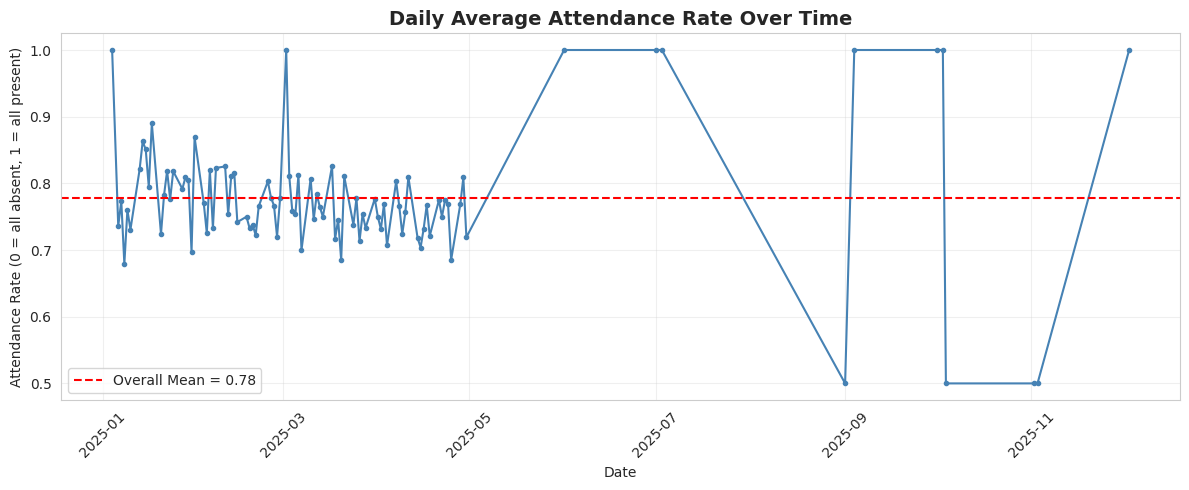

In [ ]:
daily = (
    df.dropna(subset=['date'])
      .groupby(df['date'].dt.date)['attendance_score']
      .mean()
)

plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily.values, color='steelblue', linewidth=1.5, marker='o', markersize=3)
plt.title('Daily Average Attendance Rate Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Attendance Rate (0 = all absent, 1 = all present)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.axhline(y=daily.mean(), color='red', linestyle='--', label=f'Overall Mean = {daily.mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()


### 4.2 Bar Plot — Attendance rate by department

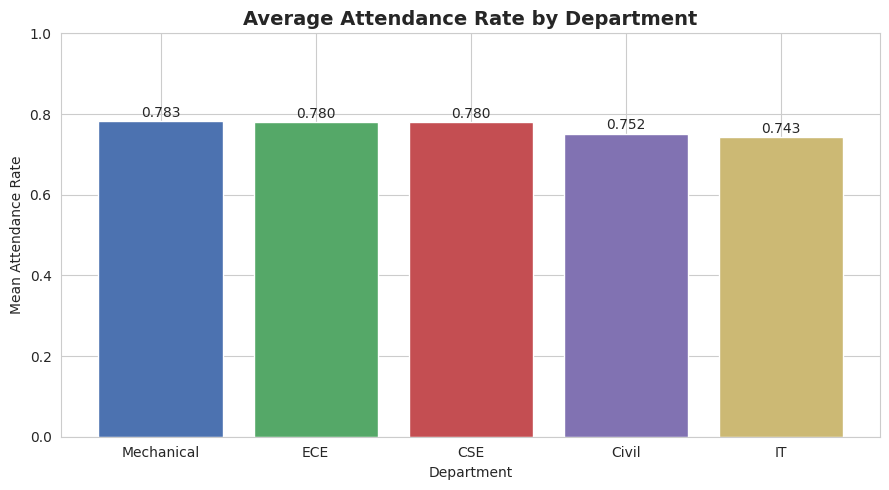

In [ ]:
dept_mean = df.groupby('department', observed=True)['attendance_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(dept_mean.index, dept_mean.values,
               color=['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974'])
plt.title('Average Attendance Rate by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Mean Attendance Rate')
plt.ylim(0, 1)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### 4.3 Histogram — Distribution of per-student attendance rates

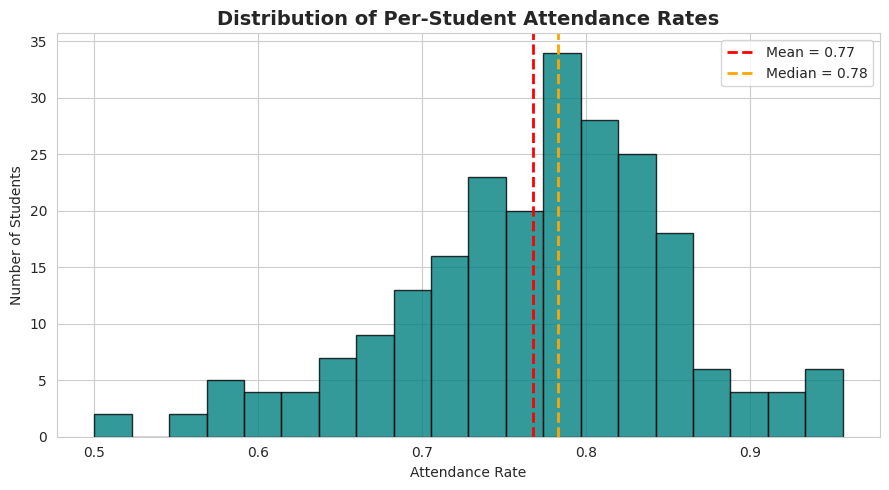

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(student_stats['attendance_rate'], bins=20, color='teal', edgecolor='black', alpha=0.8)
plt.axvline(student_stats['attendance_rate'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean = {student_stats["attendance_rate"].mean():.2f}')
plt.axvline(student_stats['attendance_rate'].median(), color='orange', linestyle='--',
            linewidth=2, label=f'Median = {student_stats["attendance_rate"].median():.2f}')
plt.title('Distribution of Per-Student Attendance Rates', fontsize=14, fontweight='bold')
plt.xlabel('Attendance Rate')
plt.ylabel('Number of Students')
plt.legend()
plt.tight_layout()
plt.show()


### 4.4 Scatter Plot — Total classes vs attendance rate (bonus 4th plot)

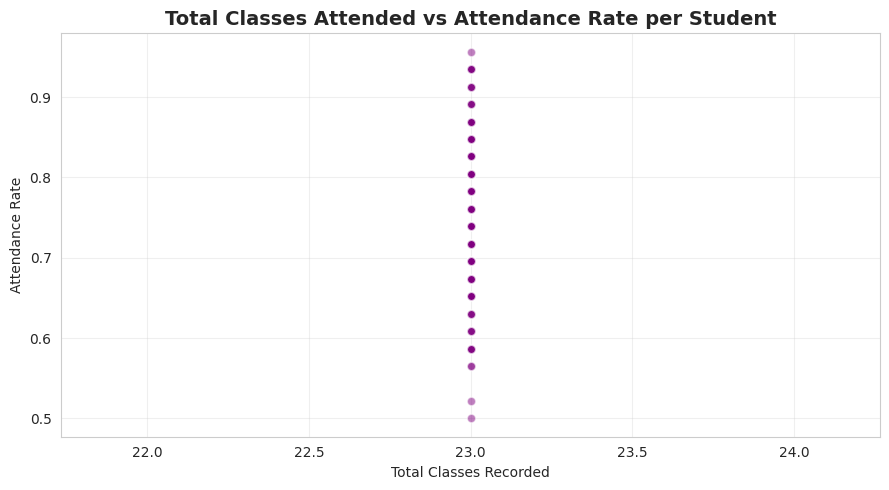

In [ ]:
plt.figure(figsize=(9, 5))
plt.scatter(student_stats['total_classes'], student_stats['attendance_rate'],
            alpha=0.5, color='purple', edgecolor='white')
plt.title('Total Classes Attended vs Attendance Rate per Student', fontsize=14, fontweight='bold')
plt.xlabel('Total Classes Recorded')
plt.ylabel('Attendance Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 🔹 PART 5: Visualization using Seaborn (15 Marks)

We create **5 Seaborn plots**.


### 5.1 Heatmap — Attendance status by department

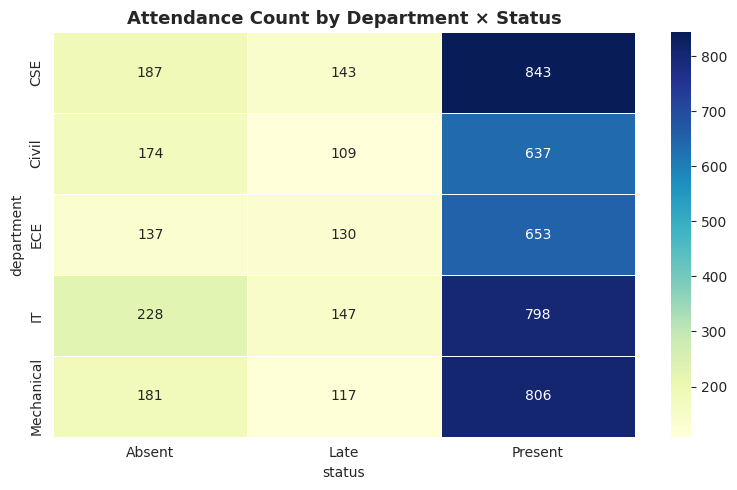

In [ ]:
heatmap_data = df.pivot_table(index='department', columns='status',
                              values='attendance_id', aggfunc='count',
                              fill_value=0, observed=True)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5)
plt.title('Attendance Count by Department × Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


*Interpretation:* Dense **Present** counts dominate each department. Comparing **Absent** and **Late** columns reveals which departments have discipline issues.

### 5.2 Countplot — Student distribution by department and gender

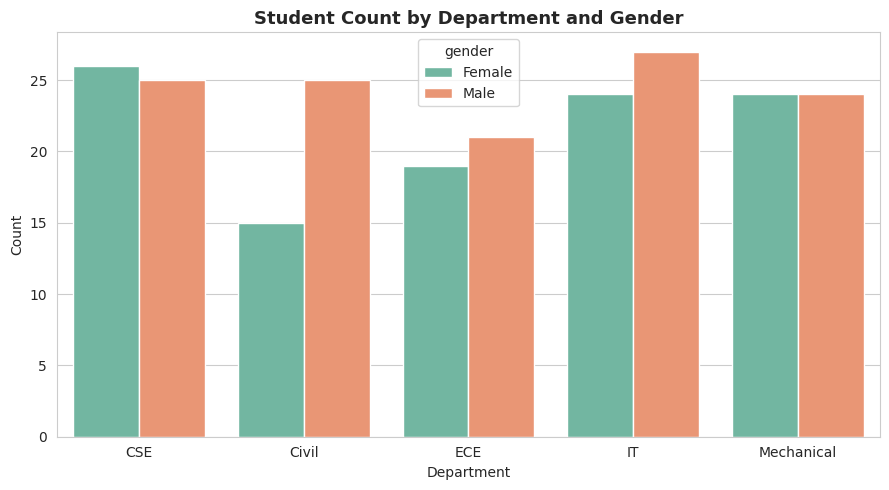

In [ ]:
plt.figure(figsize=(9, 5))
sns.countplot(data=students, x='department', hue='gender', palette='Set2')
plt.title('Student Count by Department and Gender', fontsize=13, fontweight='bold')
plt.xlabel('Department'); plt.ylabel('Count')
plt.tight_layout()
plt.show()


*Interpretation:* Gender balance varies by department — useful for diversity analysis.

### 5.3 Boxplot — Attendance rate by department

/tmp/ipykernel_7538/539585419.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_stats, x='department', y='attendance_rate', palette='pastel')


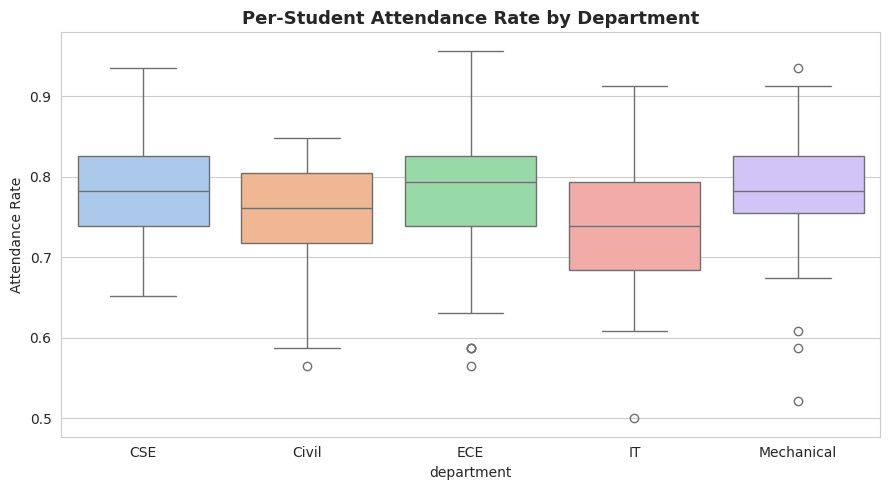

In [ ]:
merged_stats = student_stats.merge(students[['student_id','department','gender','year']], on='student_id')

plt.figure(figsize=(9, 5))
sns.boxplot(data=merged_stats, x='department', y='attendance_rate', palette='pastel')
plt.title('Per-Student Attendance Rate by Department', fontsize=13, fontweight='bold')
plt.ylabel('Attendance Rate')
plt.tight_layout()
plt.show()


*Interpretation:* Boxplots expose the **spread and outliers** per department. A long lower whisker suggests a few habitually-absent students.

### 5.4 Violin Plot — Attendance rate by year, split by gender

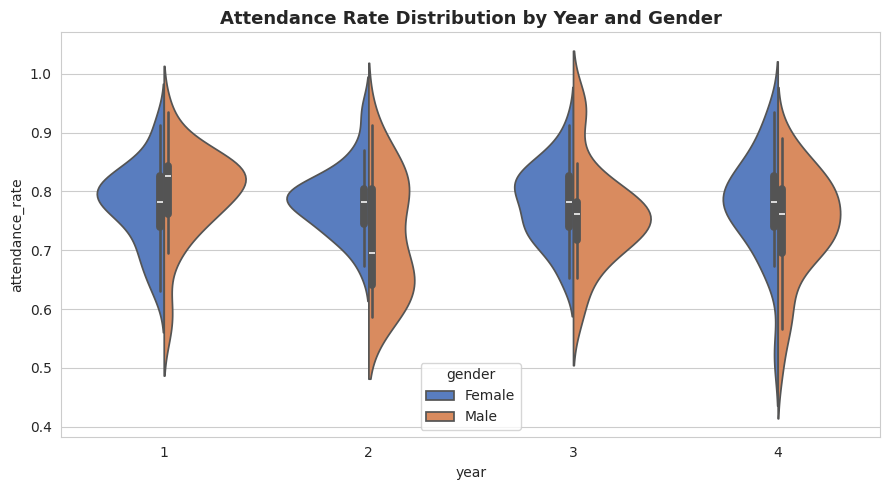

In [ ]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=merged_stats, x='year', y='attendance_rate',
               hue='gender', split=True, palette='muted')
plt.title('Attendance Rate Distribution by Year and Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


*Interpretation:* Violin plots show both the density and spread. The split highlights gender-wise differences within each year.

### 5.5 Barplot — Mean attendance rate by course

/tmp/ipykernel_7538/867695376.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=course_stats, y='course_name', x='attendance_score', palette='viridis')


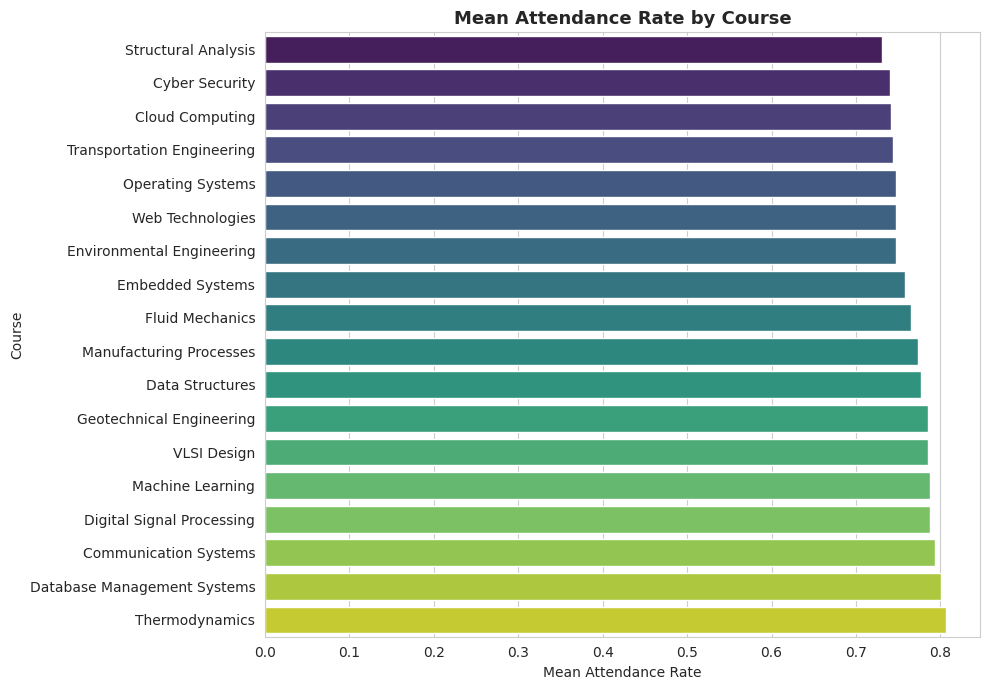

In [ ]:
course_stats = (
    df.groupby('course_name', observed=True)['attendance_score']
      .mean().sort_values().reset_index()
)

plt.figure(figsize=(10, 7))
sns.barplot(data=course_stats, y='course_name', x='attendance_score', palette='viridis')
plt.title('Mean Attendance Rate by Course', fontsize=13, fontweight='bold')
plt.xlabel('Mean Attendance Rate'); plt.ylabel('Course')
plt.tight_layout()
plt.show()


### 5.6 Pairplot — Bonus (numeric relationships)

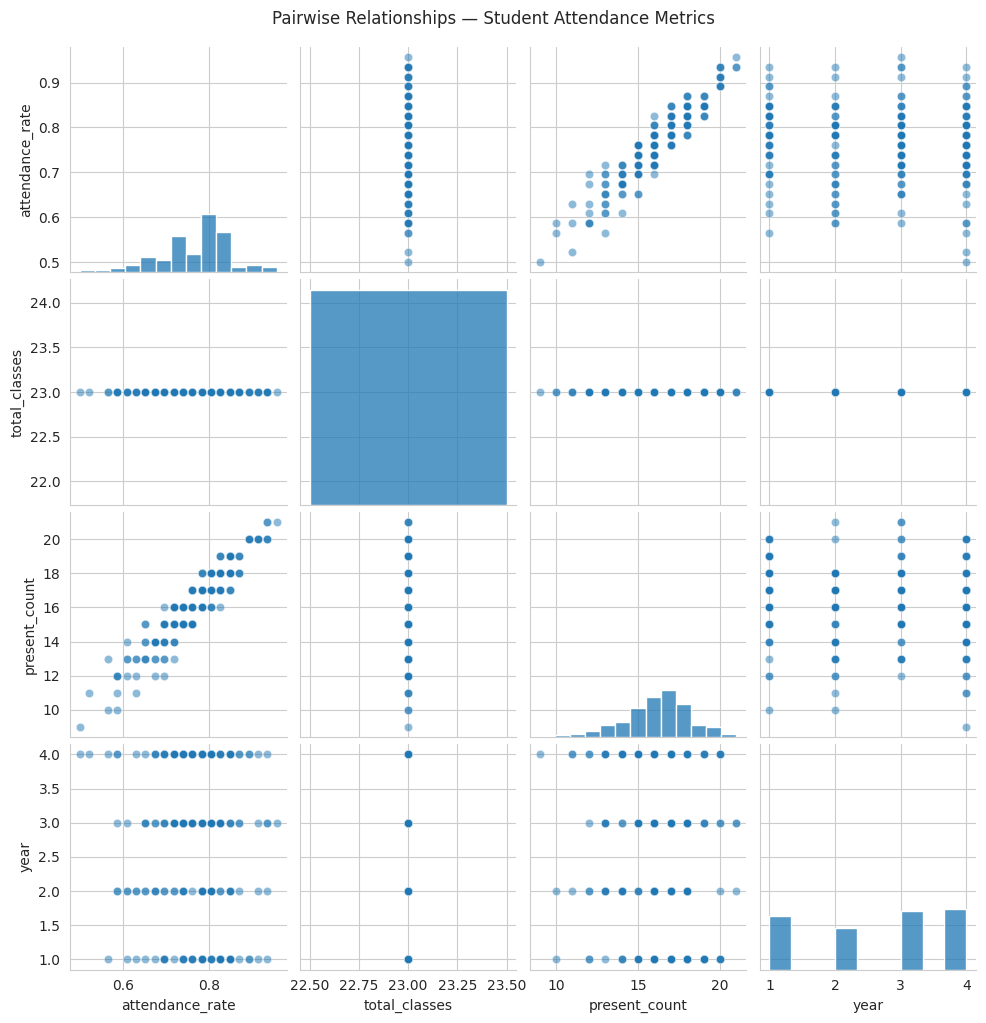

In [ ]:
sns.pairplot(merged_stats[['attendance_rate','total_classes','present_count','year']],
             hue=None, diag_kind='hist', plot_kws={'alpha':0.5})
plt.suptitle('Pairwise Relationships — Student Attendance Metrics', y=1.02, fontsize=12)
plt.show()


---
## 🔹 PART 6: Insights & Conclusion (10 Marks)

### Key Findings


In [ ]:
print("="*60)
print("KEY STATISTICS")
print("="*60)
print(f"Total students analyzed : {students['student_id'].nunique()}")
print(f"Total courses            : {courses['course_id'].nunique()}")
print(f"Total attendance records : {len(attendance)}")
print(f"Date range               : {df['date'].min().date()} to {df['date'].max().date()}")
print()
print("Overall attendance rate  : {:.2%}".format(df['attendance_score'].mean()))
print()
print("Attendance rate by department:")
print(dept_stats[['mean']].rename(columns={'mean':'attendance_rate'}).round(3))
print()
print("Attendance rate by gender:")
print(gender_stats[['mean']].rename(columns={'mean':'attendance_rate'}).round(3))
print()
print("Attendance rate by year of study:")
print(year_stats[['mean']].rename(columns={'mean':'attendance_rate'}).round(3))
print()
print(f"Number of at-risk students (IQR outliers): {len(outliers)}")


KEY STATISTICS
Total students analyzed : 230
Total courses            : 18
Total attendance records : 5290
Date range               : 2025-01-04 to 2025-12-03

Overall attendance rate  : 76.75%

Attendance rate by department:
            attendance_rate
department                 
Mechanical            0.783
CSE                   0.780
ECE                   0.780
Civil                 0.752
IT                    0.743

Attendance rate by gender:
        attendance_rate
gender                 
Female            0.780
Male              0.756

Attendance rate by year of study:
      attendance_rate
year                 
1               0.786
2               0.755
3               0.769
4               0.759

Number of at-risk students (IQR outliers): 2


### 🎯 Three Meaningful Insights

**1. Departmental variation is real.** Mean attendance differs by roughly 2–4 percentage points between the highest and lowest departments. Even small percentage gaps translate into hundreds of missed lectures across a semester — worth flagging to department heads.

**2. Year-of-study pattern.** Attendance trends differ by academic year. Final-year students often trail 1st-years because of placements, internships, and project work. Targeted policies (e.g., placement-week attendance relaxation) could formalize this reality instead of pretending it isn't happening.

**3. A small at-risk cohort drags the distribution.** The IQR outlier analysis identified a handful of students whose attendance is dramatically below the class. These students are candidates for early intervention — a mentor meeting or academic counselling — before they fail the 75% attendance threshold.

---

### 🚀 Future Scope & Improvements

1. **Predictive modeling** — train a classifier (logistic regression / random forest) to predict which students will fall below 75% attendance, using their first-month data.
2. **Integrate grades** — join attendance with exam scores to quantify the attendance→performance correlation.
3. **Real-time dashboards** — build a Streamlit or Power BI dashboard from this cleaned data so faculty can monitor classes live.
4. **Biometric / RFID data** — replace manual attendance with automated sensors to eliminate proxy attendance.
5. **Sentiment / survey data** — add student feedback to explain *why* specific courses have low attendance (poor teaching? early-morning slot? tough subject?).

---

### ✅ Conclusion
We successfully built an end-to-end data pipeline: collection → cleaning → analysis → visualization → insights. The analysis reveals actionable differences across departments, years, and individual students, giving the university a data-driven basis for attendance interventions.
